# Apuntes Spark: Trabajar con Pandas vs aplicacion Spark

En este cuaderno vamos a realizar una serie de actividades de gestion y analitica de datos, duplicando o generando simultaneamente tareas utilizando 2 herramientas complementarias

**La libreria pandas en Python y Spark a traves de una maquina virtual**

Lo primero en lo que nos vamos a detener es la reflexion sobre las diferencias entre estos 2 aplicativos

## Caracteristicas de Pandas

- **Es una libreria para trabajar con datos, del lenguaje python**, que dispone de una abstraccion de datos, *los dataframes*, que nos permiten **manejar datos de forma tabular, con estructuras de columnas y filas** (columnas = atributos o propiedades, filas = registro o entidad).
> Tambien permite trabajar con *series*, una columna de un dataframe puede ser entendida como una serie.
- Los datos de los dataframes, **se trabajan en memoria y en nuestro equipo local**
- Las operaciones que lancemos con estos datos, **se realizan al instante en nuestro equipo local**

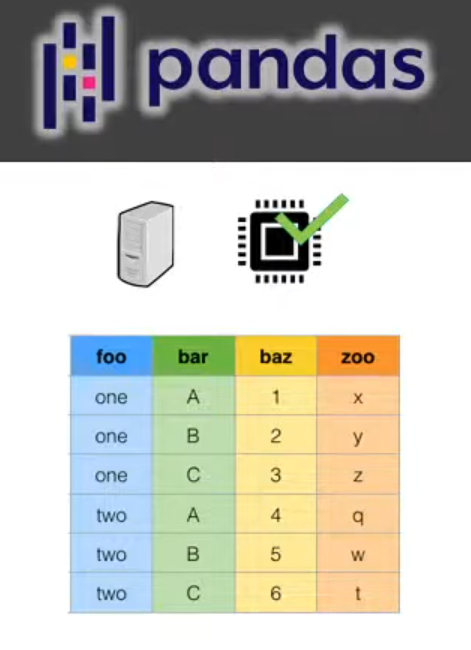

## Caracteristicas de Spark

- **Es una plataforma de calculo distribuido para trabajar datos big data**, haciendo uso de una red de ordenadores o servidores interconectados entre si.
> La plataforma nos permite interactuar con ella y trabajar los datos con un lenguaje de programacion como Python u otros.
- Los datos que manejemos en dataframes, **van a estar troceados y distribuidos entre la memoria de los equipos del cluster**
- Las operaciones que lancemos con estos datos, **se ejecutaran de manera diferida y en paralelo entre las distintas maquinas, *nodos*, para obtener las porciones de resultados parciales** 
> Al recibir las ordenes de ejecucion, las evaluara y planificara un plan de actuacion, a la espera de realizar la distribucion de tareas entre los nodos del cluster para obtener los resultados **hasta que el usuario solicite ver los resultados (print, guardarlos o extraerlos)**

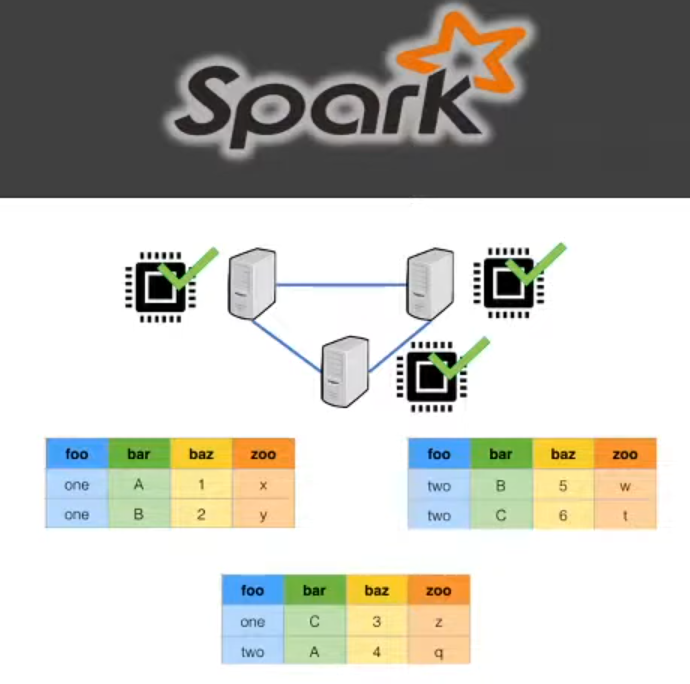


## Codigo en Pandas vs codigo en Spark

A continuacion veremos ejemplos de codigo comparado **PRIMERO EN PANDAS, LUEGO EN SPARK**

La idea es que realicen una misma actividad o similar y veamos la diferencias **de sintaxis y logica (si la hubiera)**

### CARGAR DATOS

> Hay que añadir el comentario de que en Spark, dado que esta preparado para trabajar con datos en un sistema distribuido, **si trabajamos con archivos locales deberemos indicarselo (*file://*)**

In [7]:
# EN PANDAS

from pathlib import Path
import pandas as pd
RUTA1 = Path(r"C:\proyecto-faust\M02_Python_Librerias_Big_Data\UX_Material_Extra_Librerias\U10_datasets\movie_rating.csv")
RUTA2 = Path(r"C:\proyecto-faust\M02_Python_Librerias_Big_Data\UX_Material_Extra_Librerias\U10_datasets\movie_genres.csv")
movie_rating = pd.read_csv(RUTA1, sep = ";", header = 0)
movie_genres = pd.read_csv(RUTA2, sep = ";", header = 0)

In [ ]:
# EN SPARK

movie_rating = spark.read.csv(r"file:///M02_Python_Librerias_Big_Data/UX_Material_Extra_Librerias/U10_datasets/movie_rating.csv", 
                             header = True,
                             sep =  ";"
                             inferSchema = True)
movie_genres = spark.read.csv(r"file:///M02_Python_Librerias_Big_Data/UX_Material_Extra_Librerias/U10_datasets/movie_genres.csv",
                             header = True,
                             sep = ";"
                             inferSchema = True)

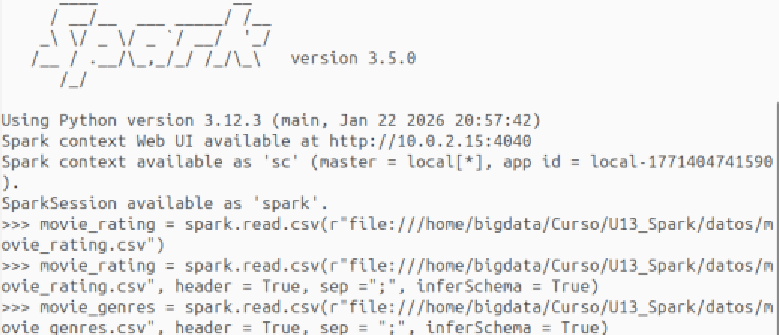

### VER TIPO DE DATAFRAME
> **No se puede trabajar con dataframes de pandas en pyspark y viceversa**

In [8]:
# EN PANDAS

type(movie_rating)

pandas.core.frame.DataFrame

In [ ]:
# EN SPARK

type(movie_rating)

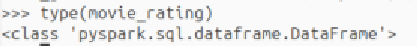

### MOSTRAR DATOS
>**Para mostrar los datos principales, existen mas modos en Spark, segun como se busque**

In [9]:
# EN PANDAS

movie_rating.head(5)

,movie_title,imdb_score,movie_facebook_likes
0,Avatar,7.9,33000
1,Pirates of the Caribbean: At World's End,7.1,0
2,Spectre,6.8,85000
3,The Dark Knight Rises,8.5,164000
4,Star Wars: Episode VII - The Force Awakens,7.1,0


In [ ]:
# EN SPARK

movie_rating.head(5)
#mostrara unicamente la informacion de las 5 primeras filas en bruto, no una tabla

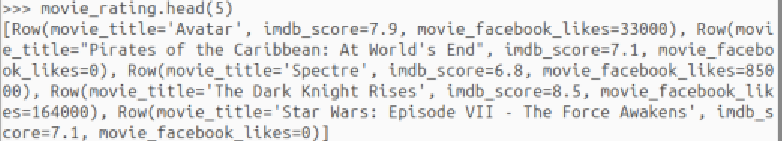

In [ ]:
# EN SPARK

movie_rating.show(5)
#mostrara una tabla con las filas indicadas

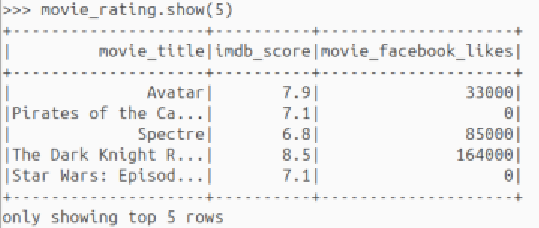

In [ ]:
# EN SPARK

movie_rating.limit(5).toPandas()
#mostrara la tabla en formato dataframe pandas, explicamos en detalle:
    # .toPandas() recopila la informacion de todos los nodos y genera un dataframe de pandas.
    # se añade un .limit() para que no convierta todo el dataframe de Spark a un dataframe de Pandas
    # hay que importar pandas a tu SparkSession

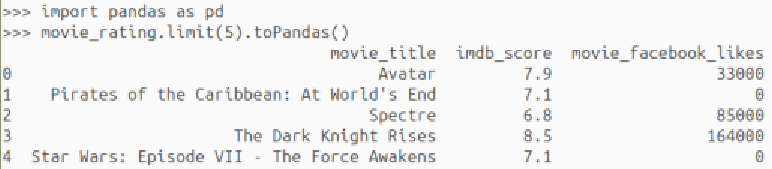

### RESUMEN ESTADISTICO
>**Si hay valores o informacion con aspecto numerico (no completamente string), Spark nos lo mostrara en el resumen estadistico como numero**
>
> La informacion mostrada en Spark con .describe(), dispone de menos indicadores estadisticos que en pandas

In [10]:
# EN PANDAS

movie_rating.describe()

,imdb_score,movie_facebook_likes
count,5043.000000,5043.000000
mean,6.442138,7525.964505
std,1.125116,19320.445110
min,1.600000,0.000000
25%,5.800000,0.000000
50%,6.600000,166.000000
75%,7.200000,3000.000000
max,9.500000,349000.000000


In [ ]:
# EN SPARK

movie_rating.describe().show()

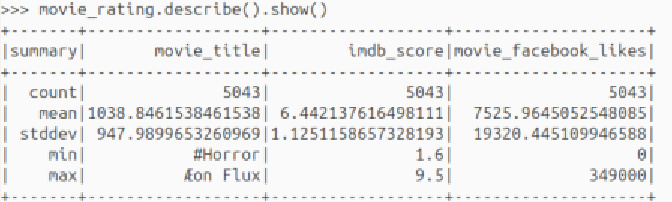

In [ ]:
# EN SPARK

movie_rating.summary().show()
# Esta funcion muestra la misma cantidad de parametros estadisticos de .describe() en pandas

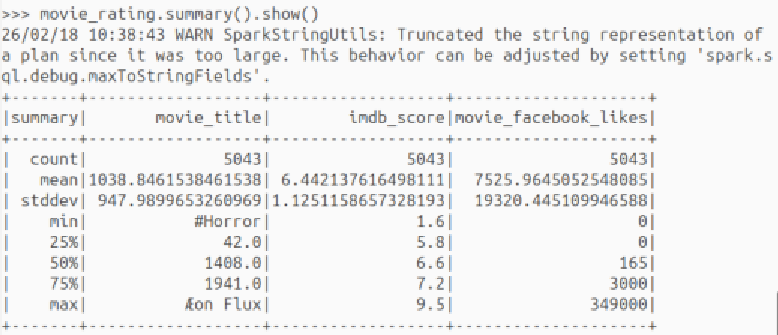

### SELECCION DE COLUMNAS (POR NOMBRE, NO POR POSICION)
> En pandas .loc[] **tiene 2 argumentos, el 1º es la seleccion de filas, el 2º seleccion de columnas**
>
> > Podemos incluir" : " **para seleccionar todos los elementos**
> >
> > Podemos incluir listas "[...,...]" **para seleccionar varios elementos concretos**

In [11]:
# EN PANDAS

movie_rating.loc[:,["movie_title", "imdb_score"]].head(5)
# Añadimos .head() para mostrar unicamente unas pocas filas.

,movie_title,imdb_score
0,Avatar,7.9
1,Pirates of the Caribbean: At World's End,7.1
2,Spectre,6.8
3,The Dark Knight Rises,8.5
4,Star Wars: Episode VII - The Force Awakens,7.1


In [ ]:
# EN SPARK

movie_rating.select("movie_title", "imdb_score").show(5)
# Hay que incluir el .show() para mostrar y ejecutar la seleccion, sino solo indicara el tipo de dataframe que devolvera.

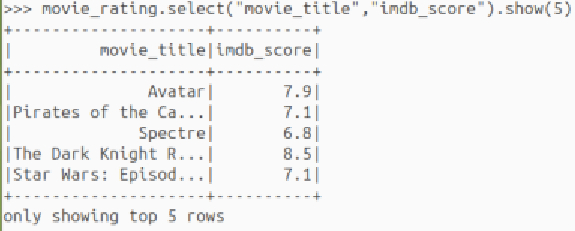

### SELECCION DE FILAS (POR POSICION)
> En pandas .iloc[] **tiene 2 argumentos, el 1º es la seleccion de filas, el 2º seleccion de columnas**
>
> **EN SPARK NO PUEDE REALIZARSE** por la naturaleza distribuida de los datos en los nodos, ya que los datos no son extraibles en posiciones concretas
>
> > Tecnicamente es posible pero no eficiente y no obvio (al repartirse, no sabemos como son los indices, en que fraccion se han repartido...)

In [14]:
# EN PANDAS

movie_rating.iloc[0:5,]

,movie_title,imdb_score,movie_facebook_likes
0,Avatar,7.9,33000
1,Pirates of the Caribbean: At World's End,7.1,0
2,Spectre,6.8,85000
3,The Dark Knight Rises,8.5,164000
4,Star Wars: Episode VII - The Force Awakens,7.1,0


In [ ]:
# EN SPARK

#NO ES POSIBLE REALIZAR ESTA SELECCION MEDIANTE POSICION.

### SELECCION DE FILAS FILTRADAS (CON 1 CONDICION BOOLEANA)
> En el caso de Spark **tanto .where() como .filter() tienen la misma funcion y misma sintaxis si NO UTILIZAMOS col()**

In [16]:
# EN PANDAS A TRAVES DE .LOC[]

movie_rating.loc[movie_rating["imdb_score"]>8.5].head()

,movie_title,imdb_score,movie_facebook_likes
66,The Dark Knight,9.0,37000
96,Interstellar,8.6,349000
97,Inception,8.8,175000
270,The Lord of the Rings: The Fellowship of the Ring,8.8,21000
339,The Lord of the Rings: The Return of the King,8.9,16000


In [18]:
# EN PANDAS A TRAVES DE .QUERY()

movie_rating.query("imdb_score > 8.5").head()

# .query() procesa una cadena de texto como un .loc, 
    # identifica aquellas partes de la cadena que pertenecen a nombres de columnas y es capaz de realizar la comparacion indicada

,movie_title,imdb_score,movie_facebook_likes
66,The Dark Knight,9.0,37000
96,Interstellar,8.6,349000
97,Inception,8.8,175000
270,The Lord of the Rings: The Fellowship of the Ring,8.8,21000
339,The Lord of the Rings: The Return of the King,8.9,16000


In [ ]:
# EN SPARK A TRAVES DE .WHERE() con col()

from pyspark.sql.functions import col

movie_rating.where(col("imdb_score") > 8.5).show(5)


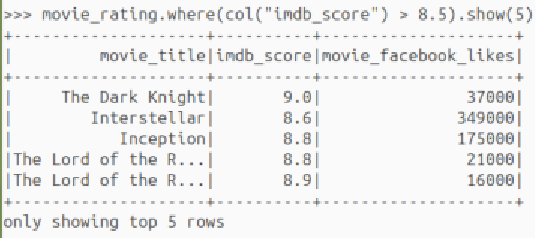

In [ ]:
# EN SPARK A TRAVES DE .WHERE() o .FILTER() sin col()

movie_rating.where("imdb_score > 8.5").show(5)
movie_rating.filter("imdb_score > 8.5").show(5)
# Se puede expresar de 2 maneras distintas pero daran el mismo resultado.
    # como si fuera una consulta de WHERE en SQL

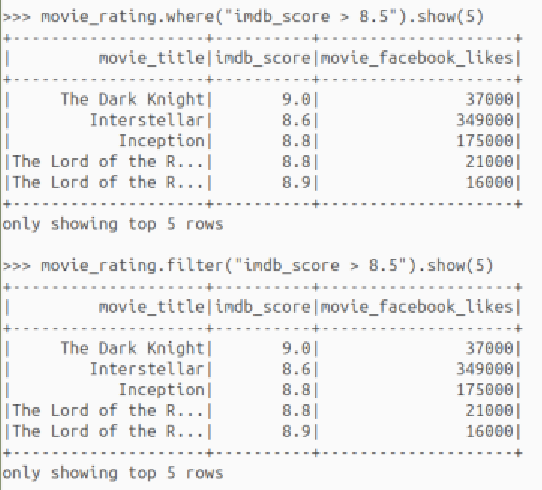

### SELECCION DE FILAS FILTRADAS (CON VARIAS CONDICIONES BOOLEANA)
> En pandas si utilizamos .loc[] **debemos utilizar operadores logicos de pandas** y usando .query() **los operadores logicos de python**.
>
> En Spark si utilizamos col() **debemos utilizar operadores logicos de pandas** y sino no.
> 
> A continuacion se ven los que se utilizan en uno y en otro.
>
> > "&" = *and* (o cuando 2 condiciones se deben cumplir simultaneamente)
> >
> > "|" = *or* (o cuando 1 o 2 condiciones se deben cumplir)
> >
> > "!" = *not* (o cuando 2 condiciones no se deben cumplir simultaneamente)

In [19]:
# EN PANDAS A TRAVES DE .LOC[], USAMOS LOS OPERADORES &, |, !

movie_rating.loc[(movie_rating["imdb_score"]>5) & (movie_rating["imdb_score"]< 8.5)].head()

,movie_title,imdb_score,movie_facebook_likes
0,Avatar,7.9,33000
1,Pirates of the Caribbean: At World's End,7.1,0
2,Spectre,6.8,85000
4,Star Wars: Episode VII - The Force Awakens,7.1,0
5,John Carter,6.6,24000


In [21]:
# EN PANDAS A TRAVES DE .QUERY(), USAMOS LOS OPERADORES AND, OR, NOT

movie_rating.query("imdb_score > 5 and imdb_score < 8.5").head()

,movie_title,imdb_score,movie_facebook_likes
0,Avatar,7.9,33000
1,Pirates of the Caribbean: At World's End,7.1,0
2,Spectre,6.8,85000
4,Star Wars: Episode VII - The Force Awakens,7.1,0
5,John Carter,6.6,24000


In [ ]:
# EN SPARK A TRAVES DE .WHERE() con col(), USAMOS LOS OPERADORES &, |, !

from pyspark.sql.functions import col

movie_rating.where((col("imdb_score") > 5) & (col("imdb_score") < 8.5)).show(5)
# Se utilizan () para indicar la jerarquia de orden de operaciones 

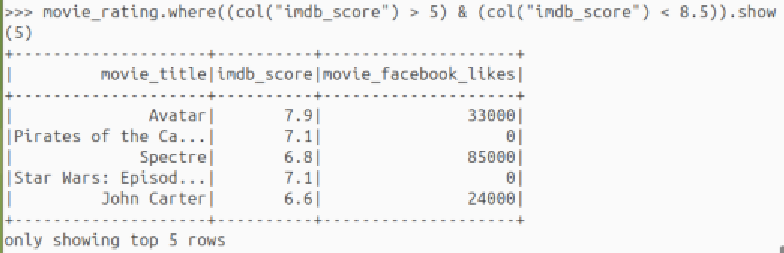

In [ ]:
# EN SPARK A TRAVES DE .WHERE() o .FILTER() sin col(), USAMOS LOS OPERADORES AND, OR, NOT

movie_rating.where("imdb_score > 5 and imdb_score < 8.5").show(5)
movie_rating.filter("imdb_score > 5 and imdb_score < 8.5").show(5)
# Se puede expresar de 2 maneras distintas pero daran el mismo resultado.
    # como si fuera una consulta de WHERE en SQL

In [ ]:
# EN SPARK SQL PODEMOS REALIZAR ESTE FILTRADO MEDIANTE LENGUAJE DE CONSULTAS
    # 1º Generando un tabla o vista de una BBDD Relacional mediante .createOrReplaceTempView()
    # 2º Realizamos la consulta en lenguaje SQL con el metodo WHERE y con los condicionantes usamos los operadores logicos de SQL.

movie_rating.createOrReplaceTempView("vw_movie_rating")
spark.sql(""" 
SELECT * 
FROM vw_movie_rating 
WHERE imdb_score > 5 AND imdb_score < 8.5
""").show(5)

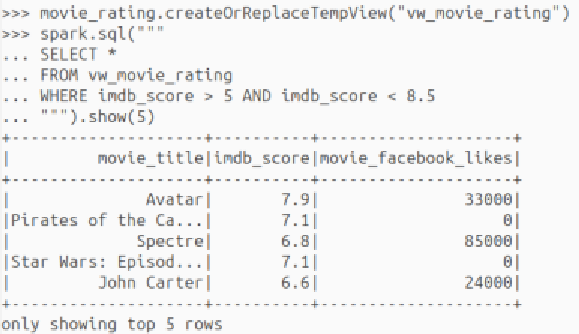

### CRUCE DE DATAFRAMES (2 o mas)
> Hemos tenido que cargar previamente 2 datasets al menos
>
> **Se pueden utilizar mas columnas para hacer el cruce**
>
> > ***on = [nombre columna 1, nombre columna 2,...]***
>
> **Se pueden cruzar mas dataframes a la vez, pero no utilizando una unica expresion, sino en varios pasos**:
>
> > En pandas usando .merge() **tendras que hacer otra funcion .merge() sobre el dataframe con el cruce ya realizado**
> >
> > En Spark usando .join() **tendremos que concatenar otra expresion .join() con el que quisieramos cruzarlo**

In [22]:
# EN PANDAS A TRAVES DE PD.MERGE()

movie_data = pd.merge(movie_rating, movie_genres, on = "movie_title")
movie_data.head()

# Hay 3 argumentos en esta funcion
    # Los 2 primeros corresponden a los nombres de los dataframes seleccionados
    # el 3º corresponde al nombre de la columna por el que se van a mezclar

,movie_title,imdb_score,movie_facebook_likes,genre
0,Avatar,7.9,33000,Action
1,Avatar,7.9,33000,Adventure
2,Avatar,7.9,33000,Fantasy
3,Avatar,7.9,33000,Sci-Fi
4,Pirates of the Caribbean: At World's End,7.1,0,Action


In [23]:
# EN PANDAS A TRAVES DE .JOIN()
    # requiere que previamente hayamos establecido como nombre del indice de las columnas en los dataframes, la columna por la que se van a unir

movie_rating.set_index("movie_title").join(movie_genres.set_index("movie_title")).head(5)

# mecla 1 dataframe encima de otro en base al nombre de los indices de las columnas que coincidan

,imdb_score,movie_facebook_likes,genre
movie_title,,,
Avatar,7.9,33000,Action
Avatar,7.9,33000,Adventure
Avatar,7.9,33000,Fantasy
Avatar,7.9,33000,Sci-Fi
Pirates of the Caribbean: At World's End,7.1,0,Action


In [ ]:
# EN SPARK A TRAVES DE .JOIN()

movie_data = movie_rating.join(movie_genres, on = ["movie_title"]).show(5)
# Crea un nuevo dataframe, en base a uno e incrusta el otro, en funcion de la columna que coincida

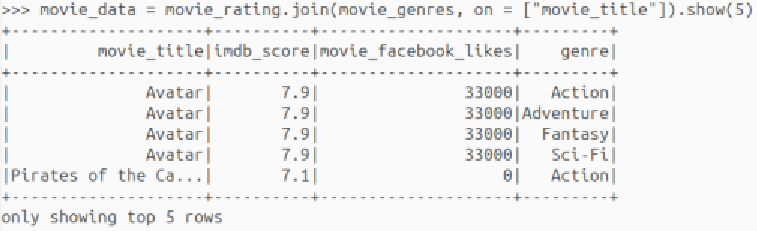

In [ ]:
# EN SPARK SQL PODEMOS REALIZAR ESTE CRUCE DE DATAFRAMES
    # 1º Generando un tabla o vista de una BBDD Relacional mediante .createOrReplaceTempView() para ambos dataframes
    # 2º Realizamos la consulta en lenguaje SQL sobre 1 de los dataframe, el metodo JOIN. sobre el otro de los dataframes y USING para definir la columna 

movie_genres.createOrReplaceTempView("vw_movie_genres")
movie_rating.createOrReplaceTempView("vw_movie_rating")
spark.sql(""" 
SELECT * 
FROM vw_movie_rating 
JOIN vw_movie_genres USING (movie_title)
""").show(5)

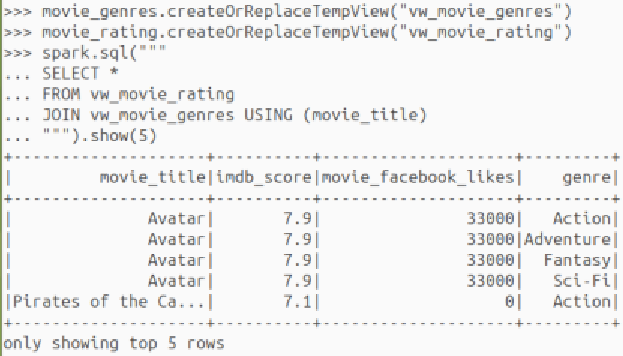

### AGREGACIONES EN DATAFRAMES (AGRUPANDO POR 1 O MAS COLUMNAS)
> En pandas **si nos piden un calculo *por lo que sea* siempre sera mediante un *.groupby()***

In [24]:
# EN PANDAS SI QUEREMOS AGRUPAR POR UNA COLUMNA Y CONTABILIZAR LOS TOTALES EN GENERAL: .GROUPBY() + .COUNT()

movie_data.groupby(["genre"]).count().head()

# Asi agregamos en un subgrupo definido en []

,movie_title,imdb_score,movie_facebook_likes
genre,,,
Action,1238,1238,1238
Adventure,1002,1002,1002
Animation,248,248,248
Biography,297,297,297
Comedy,1923,1923,1923


In [25]:
# EN PANDAS SI QUEREMOS CONOCER EL Nº TOTAL DE ELEMENTOS DEL GRUPO SELECCIONADO: .GROUPBY() + .SIZE()

movie_data.groupby(["genre"]).size().head()

# Asi agregamos en un subgrupo definido en []

genre
Action       1238
Adventure    1002
Animation     248
Biography     297
Comedy       1923
dtype: int64

In [26]:
# EN PANDAS SI QUEREMOS CONOCER PARAMETROS CONCRETOS (MEDIAS, Nº ELEMENTOS...) PARA CADA COLUMNA A PARTIR DEL GRUPO SELECCIONADO: .GROUPBY() + .AGGREGATE()

movie_data.groupby(["genre"]).aggregate({"movie_title":"count", "imdb_score": "mean", "movie_facebook_likes":"mean"}).head()

# Es necesario crear un diccionario clave-valor para seleccionar las columnas con sus parametros buscados

,movie_title,imdb_score,movie_facebook_likes
genre,,,
Action,1238,6.257674,11122.877221
Adventure,1002,6.445908,13893.893214
Animation,248,6.579032,7623.326613
Biography,297,7.152862,11238.898990
Comedy,1923,6.200208,5142.248570


In [ ]:
# EN SPARK SI QUEREMOS AGRUPAR POR UNA COLUMNA Y CONTABILIZAR LOS TOTALES EN GENERAL: .GROUPBY() + .COUNT()

movie_data.groupBy("genre").count().show(5)

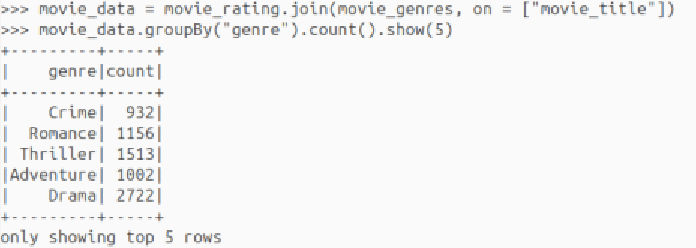

In [ ]:
# EN SPARK SI QUEREMOS CONOCER PARAMETROS CONCRETOS (MEDIAS, Nº ELEMENTOS...) PARA CADA COLUMNA A PARTIR DEL GRUPO SELECCIONADO: .GROUPBY() + .AGG()

movie_data.groupBy("genre").agg({"movie_title":"count", "imdb_score": "avg", "movie_facebook_likes":"avg"}).show(5)

# Es necesario crear un diccionario clave-valor para seleccionar las columnas con sus parametros buscados
    # Cambian los "mean" por "avg"

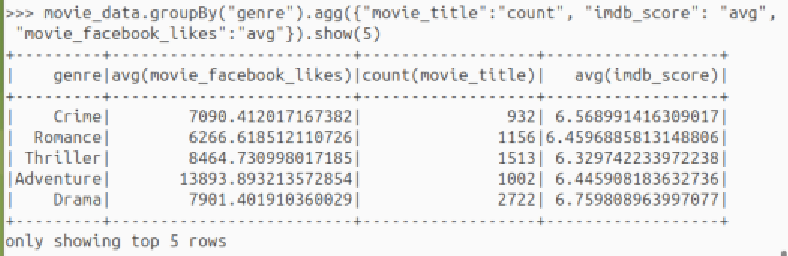

In [ ]:
# EN SPARK SQL PODEMOS REALIZAR ESTE CRUCE DE DATAFRAMES
    # 1º Generando un tabla o vista de una BBDD Relacional mediante .createOrReplaceTempView() para ambos dataframes
    # 2º Realizamos la consulta en lenguaje SQL del siguiente modo:
        # Se seleccionan los parametros que queremos que nos muestre con SELECT
        # Se escoge el dataframe del que va a coger los datos con FROM
        # Se le indica por que grupo queremos que haga los calculos con GROUP BY
movie_data.createOrReplaceTempView("vw_movie_data")
spark.sql(""" 
SELECT genre, count(*), avg(imdb_score) AS avg_imdb_score, avg(movie_facebook_likes) AS movie_facebook_likes
FROM vw_movie_data
GROUP BY genre
""").show(5)

# Utilizamos AS como alias para las columnas que nos interesen

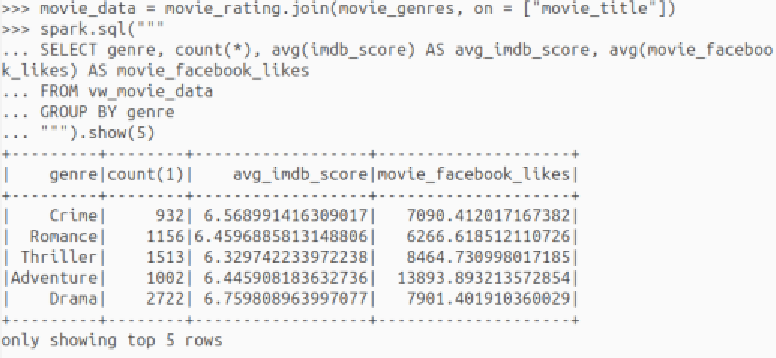